# London Smart Meter — Energy & Weather Analysis

By:  Terje Sørbø og Ørjan Tornvik
Group name: Terje og Ørjan si gruppe

**Household:** MAC000002  
**Energy data:** Half-hourly kWh readings, Oct 2012 – Feb 2014  
**Weather (hourly):** Temperature, wind speed, humidity, visibility — Heathrow area  
**Weather (daily):** Sunshine hours, precipitation, cloud cover, snow depth — Heathrow (Kaggle: emmanuelfwerr/london-weather-data)  

### Objectives
1. Identify dependencies between weather parameters and electricity consumption
2. Engineer time-series features (lags, rolling averages, time-of-day indicators)
3. Test for stationarity and decompose the consumption series
4. Build AR, MA, and ARMA forecasting models with 48-hour horizon

---

## Part 1 — Loading data

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded.')

Libraries loaded.


### 1.1 Load energy data (half hour intervals)

In [7]:
energy_raw = pd.read_csv(
    'MAC000002_energy_halfhourly.csv',
    parse_dates=['time']
)

# Strip whitespace and coerce to float
energy_raw['energy(kWh/hh)'] = pd.to_numeric(
    energy_raw['energy(kWh/hh)'].astype(str).str.strip(), errors='coerce'
)
energy_raw = energy_raw.sort_values('time').reset_index(drop=True)

print(f'Date range: {energy_raw["time"].min()} → {energy_raw["time"].max()}')
print(f'Missing values:\n{energy_raw.isnull().sum()}')
energy_raw.head()

Date range: 2012-10-12 00:30:00 → 2014-02-28 00:00:00
Missing values:
time              0
LCLid             0
energy(kWh/hh)    1
dtype: int64


,time,LCLid,energy(kWh/hh)
0,2012-10-12 00:30:00,MAC000002,0.0
1,2012-10-12 01:00:00,MAC000002,0.0
2,2012-10-12 01:30:00,MAC000002,0.0
3,2012-10-12 02:00:00,MAC000002,0.0
4,2012-10-12 02:30:00,MAC000002,0.0


In [8]:
# Drop the single null row
energy_raw = energy_raw.dropna(subset=['energy(kWh/hh)'])

# Half hour to hourly aggregation
energy_hourly = (
    energy_raw
    .assign(time_hour=energy_raw['time'] - pd.Timedelta(minutes=30))
    .set_index('time_hour')['energy(kWh/hh)']
    .resample('h')
    .sum()
    .rename('energy_kwh')
    .reset_index()
    .rename(columns={'time_hour': 'time'})
)

energy_hourly.head()

,time,energy_kwh
0,2012-10-12 00:00:00,0.0
1,2012-10-12 01:00:00,0.0
2,2012-10-12 02:00:00,0.0
3,2012-10-12 03:00:00,0.0
4,2012-10-12 04:00:00,0.0


### 1.2 Load weather data

In [9]:
weather_hourly = pd.read_csv(
    'London_weather_hourly.csv',
    parse_dates=['time']
)

# Keep only the columns we need from hourly weather
hourly_cols = ['time', 'temperature', 'windSpeed', 'humidity', 'pressure']
weather_hourly = weather_hourly[hourly_cols].copy()

# Fill the 13 missing pressure values with forward-fill
weather_hourly['pressure'] = weather_hourly['pressure'].ffill()

print(f'Date range: {weather_hourly["time"].min()} → {weather_hourly["time"].max()}')
print(f'Missing values:\n{weather_hourly.isnull().sum()}')
weather_hourly.head()

Date range: 2011-11-01 00:00:00 → 2014-03-31 22:00:00
Missing values:
time           0
temperature    0
windSpeed      0
humidity       0
pressure       0
dtype: int64


,time,temperature,windSpeed,humidity,pressure
0,2011-11-11 00:00:00,10.24,2.77,0.91,1016.76
1,2011-11-11 01:00:00,9.76,2.95,0.94,1016.63
2,2011-11-11 02:00:00,9.46,3.17,0.96,1016.36
3,2011-11-11 03:00:00,9.23,3.25,0.96,1016.28
4,2011-11-11 04:00:00,9.26,3.70,1.00,1015.98


### 1.3 Load daily weather data  
This dataset provides **sunshine hours**, **precipitation (mm)**, **cloud cover (oktas)**, and **snow depth (cm)** — columns not available at hourly intervals. Each daily value is added to the hourly value.

In [10]:
weather_daily = pd.read_csv('london_weather.csv')

# Parse integer YYYYMMDD date column
weather_daily['date'] = pd.to_datetime(
    weather_daily['date'].astype(str), format='%Y%m%d'
)

# Keep only relevant daily columns
daily_cols = ['date', 'sunshine', 'precipitation', 'cloud_cover', 'snow_depth']
weather_daily = weather_daily[daily_cols].copy()

# Fill snow_depth nulls with 0 (no snow recorded)
weather_daily['snow_depth'] = weather_daily['snow_depth'].fillna(0)
# Fill remaining nulls with forward-fill
weather_daily = weather_daily.ffill()

print(f'Shape: {weather_daily.shape}')
print(f'Date range: {weather_daily["date"].min()} → {weather_daily["date"].max()}')
print(f'Missing values:\n{weather_daily.isnull().sum()}')
weather_daily.head()

Shape: (15341, 5)
Date range: 1979-01-01 00:00:00 → 2020-12-31 00:00:00
Missing values:
date             0
sunshine         0
precipitation    0
cloud_cover      0
snow_depth       0
dtype: int64


,date,sunshine,precipitation,cloud_cover,snow_depth
0,1979-01-01,7.0,0.4,2.0,9.0
1,1979-01-02,1.7,0.0,6.0,8.0
2,1979-01-03,0.0,0.0,5.0,4.0
3,1979-01-04,0.0,0.0,8.0,2.0
4,1979-01-05,2.0,0.0,6.0,1.0


### 1.4 Merge all three datasets

1. Left-join energy (by hour) - hourly weather on `time`
2. Add a `date` column to the result, then left-join - daily weather on `date`

All rows from the energy dataset are kept.

In [11]:
# Step 1: energy ← hourly weather (left join)
df = energy_hourly.merge(weather_hourly, on='time', how='left')

# Step 2: add date key and left-join daily weather
df['date'] = df['time'].dt.normalize()  # floor to midnight
df = df.merge(weather_daily, on='date', how='left')

# Drop the helper date column (keep 'time' as the primary index)
df = df.drop(columns=['date'])
df = df.set_index('time').sort_index()

print(f'Final merged shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'\nMissing values per column:')
print(df.isnull().sum())
df.head()

Final merged shape: (12096, 9)
Date range: 2012-10-12 00:00:00 → 2014-02-27 23:00:00

Missing values per column:
energy_kwh       0
temperature      2
windSpeed        2
humidity         2
pressure         2
sunshine         0
precipitation    0
cloud_cover      0
snow_depth       0
dtype: int64


,energy_kwh,temperature,windSpeed,humidity,pressure,sunshine,precipitation,cloud_cover,snow_depth
time,,,,,,,,,
2012-10-12 00:00:00,0.0,13.61,5.40,0.91,999.47,6.4,0.0,5.0,0.0
2012-10-12 01:00:00,0.0,13.09,6.77,0.89,1000.10,6.4,0.0,5.0,0.0
2012-10-12 02:00:00,0.0,12.54,6.46,0.86,1000.51,6.4,0.0,5.0,0.0
2012-10-12 03:00:00,0.0,11.94,6.37,0.84,1000.73,6.4,0.0,5.0,0.0
2012-10-12 04:00:00,0.0,11.47,6.63,0.86,1001.23,6.4,0.0,5.0,0.0


In [17]:
# Drop rows with any missing values (outside weather coverage)
# Note: There are no missing rows for the household we choose, but this is just a safe guard so we can use it on other households with missing weather data.
before = len(df)
df = df.dropna()
after = len(df)
print(f'Dropped {before - after} rows with missing values (outside weather coverage).')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.describe().round(3)

Dropped 0 rows with missing values (outside weather coverage).
Date range: 2012-10-12 00:00:00 to 2014-02-27 23:00:00


,energy_kwh,temperature,windSpeed,humidity,pressure,sunshine,precipitation,cloud_cover,snow_depth
count,12094.000,12094.000,12094.000,12094.000,12094.000,12094.000,12094.000,12094.000,12094.000
mean,0.504,9.898,4.002,0.787,1012.489,3.566,2.028,4.717,0.026
std,0.448,5.933,2.103,0.138,11.416,3.716,3.876,2.311,0.304
min,0.000,-3.860,0.040,0.230,975.740,0.000,0.000,0.000,0.000
25%,0.218,5.660,2.450,0.710,1005.460,0.200,0.000,3.000,0.000
50%,0.341,9.145,3.770,0.820,1013.465,2.500,0.200,5.000,0.000
75%,0.606,13.650,5.200,0.890,1020.550,5.675,2.400,7.000,0.000
max,4.780,32.400,14.800,1.000,1040.130,14.500,29.800,8.000,5.000


---
## Section 2 — Exploratory Data Analysis

### 2.1 Consumption over time

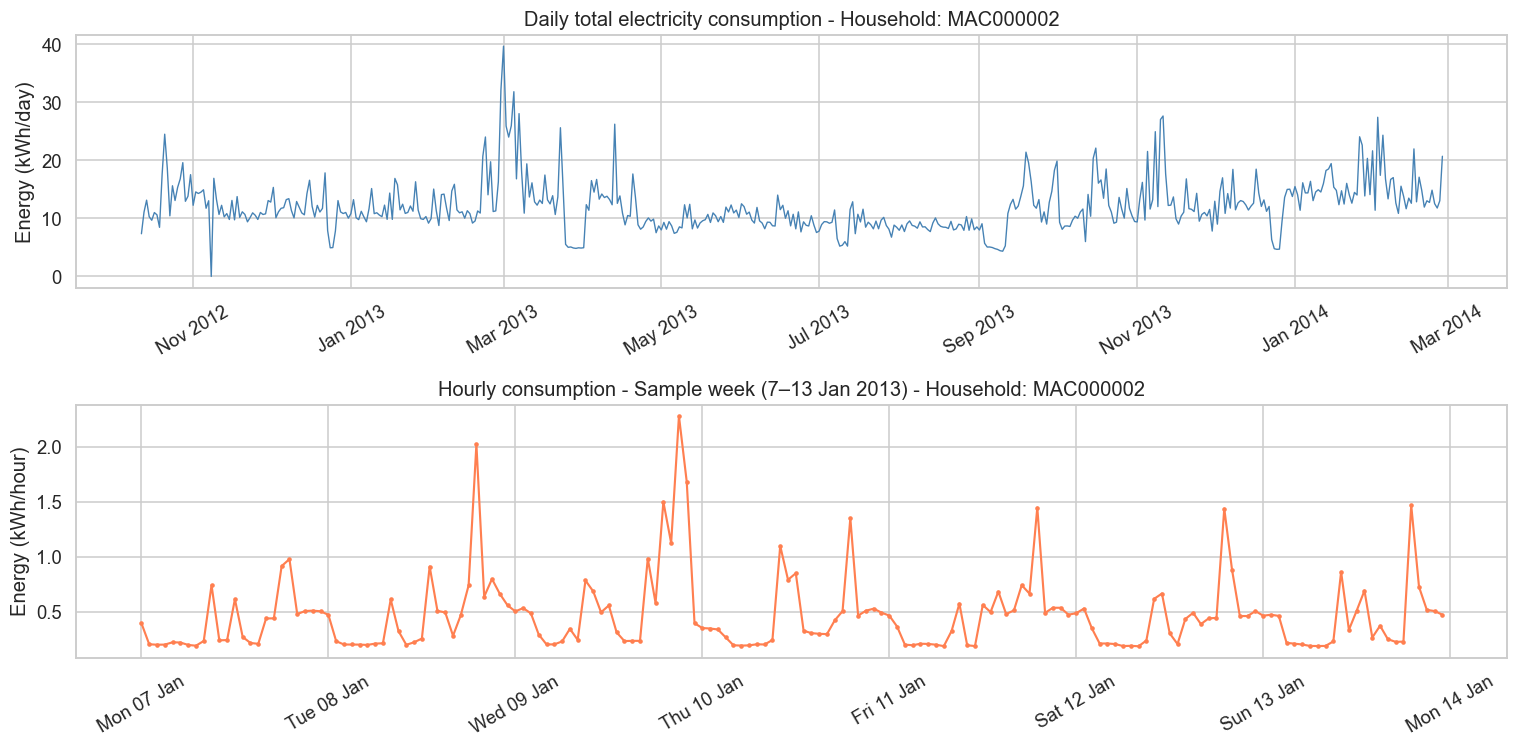

In [19]:
daily_energy = df['energy_kwh'].resample('D').sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Full period — daily total
axes[0].plot(daily_energy.index, daily_energy.values, color='steelblue', linewidth=0.9)
axes[0].set_title('Daily total electricity consumption - Household: MAC000002')
axes[0].set_ylabel('Energy (kWh/day)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# One representative week (first full week of Jan 2013)
week = df['energy_kwh']['2013-01-07':'2013-01-13']
axes[1].plot(week.index, week.values, color='coral', linewidth=1.4, marker='o', markersize=2)
axes[1].set_title('Hourly consumption - Sample week (7–13 Jan 2013) - Household: MAC000002')
axes[1].set_ylabel('Energy (kWh/hour)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.2 Heatmap — Consumption by hour of day and day of Week

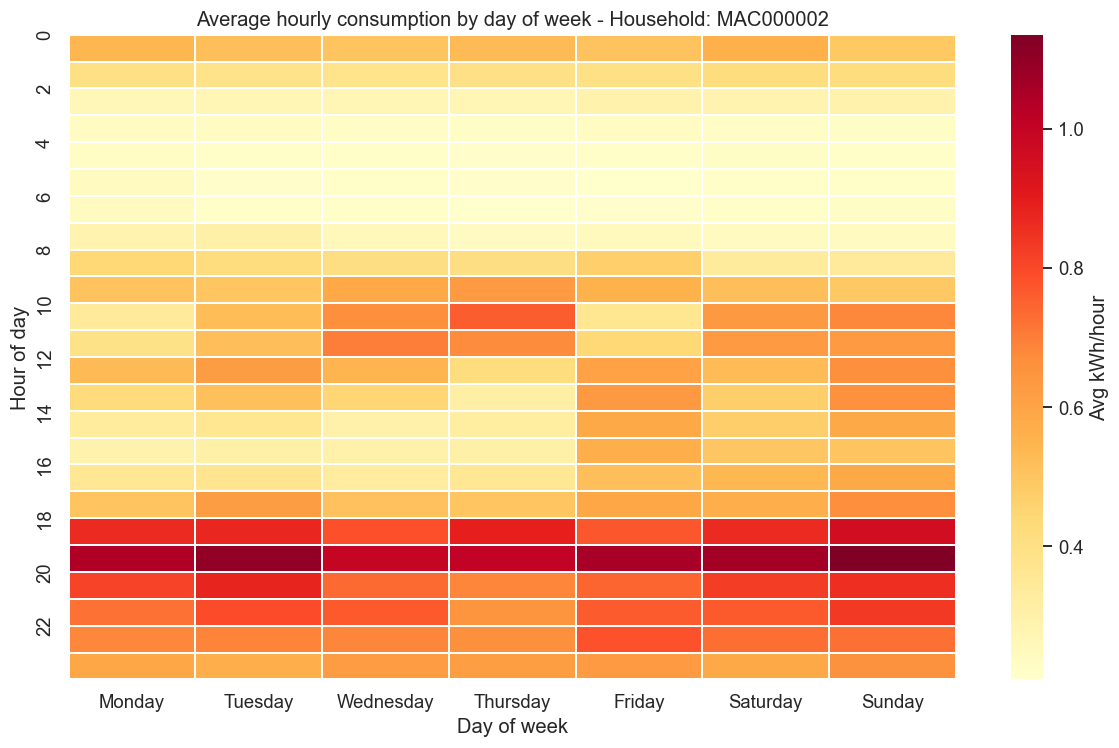

In [21]:
df_tmp = df.copy()
df_tmp['hour'] = df_tmp.index.hour
df_tmp['dayofweek'] = df_tmp.index.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df_tmp.pivot_table(
    values='energy_kwh', index='hour', columns='dayofweek', aggfunc='mean'
)[day_order]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Avg kWh/hour'}
)
ax.set_title('Average hourly consumption by day of week - Household: MAC000002')
ax.set_xlabel('Day of week')
ax.set_ylabel('Hour of day')
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
plt.tight_layout()
plt.show()

### 2.3 Seasonal Consumption Patterns

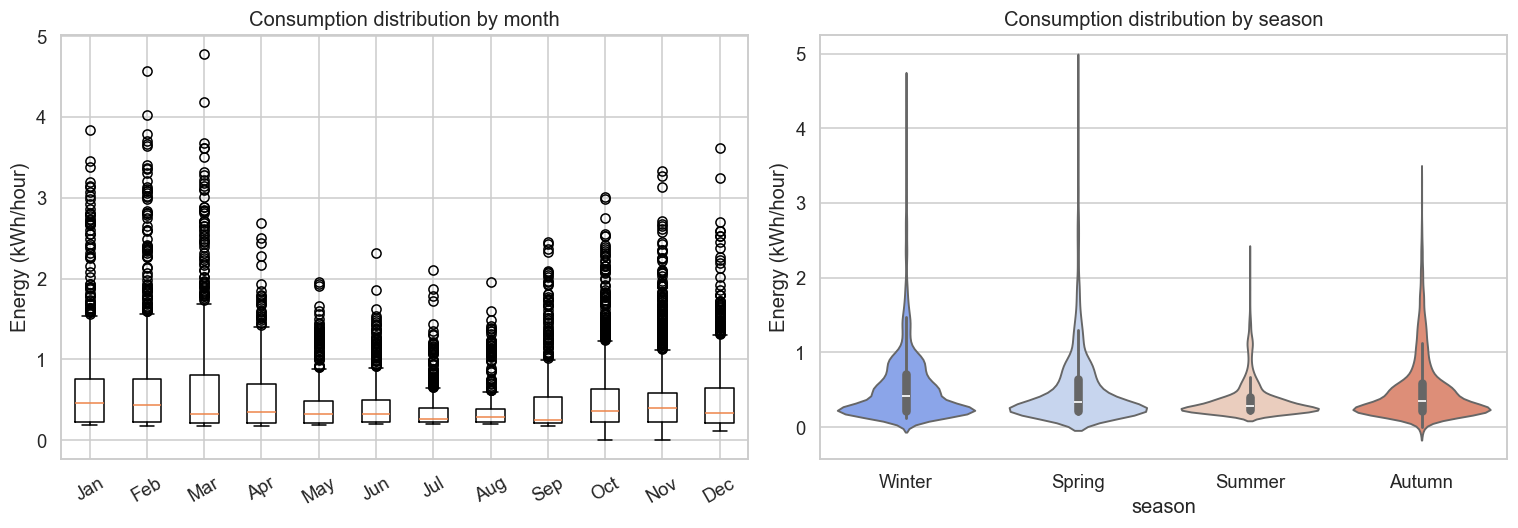

In [22]:
df_tmp = df.copy()
df_tmp['month'] = df_tmp.index.month
df_tmp['season'] = df_tmp['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by month
monthly = df_tmp.groupby('month')['energy_kwh'].apply(list)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].boxplot(
    [df_tmp[df_tmp['month']==m]['energy_kwh'].values for m in range(1,13)],
    labels=month_labels
)
axes[0].set_title('Consumption distribution by month')
axes[0].set_ylabel('Energy (kWh/hour)')
axes[0].tick_params(axis='x', rotation=30)

# Violin by season
season_order = ['Winter','Spring','Summer','Autumn']
sns.violinplot(
    data=df_tmp, x='season', y='energy_kwh',
    order=season_order, palette='coolwarm', ax=axes[1]
)
axes[1].set_title('Consumption distribution by season')
axes[1].set_ylabel('Energy (kWh/hour)')

plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap — Weather vs. consumption

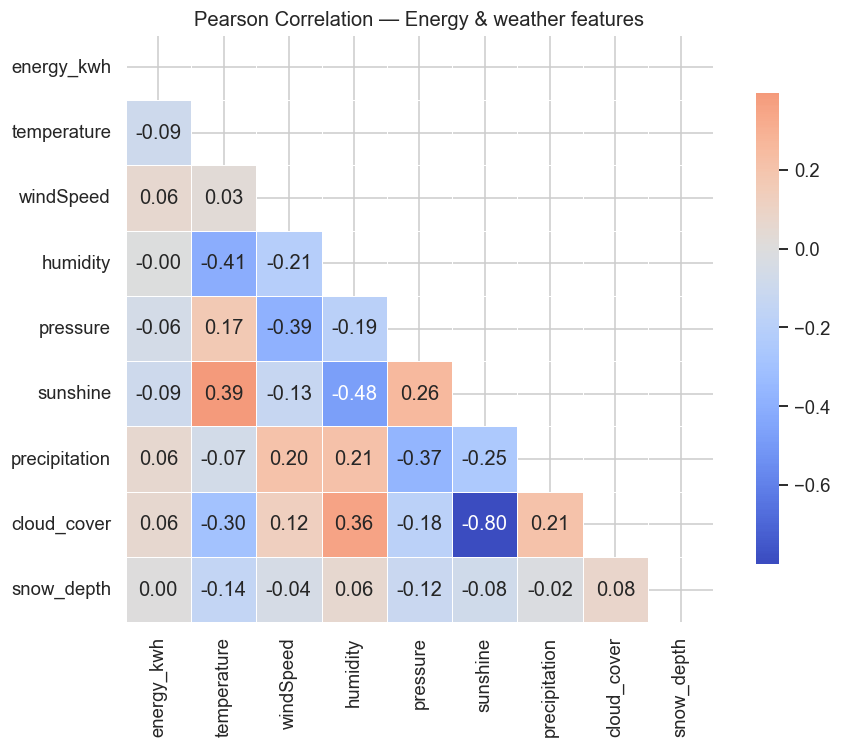


Correlation with energy_kwh (sorted):
sunshine        -0.089239
temperature     -0.086442
pressure        -0.059693
humidity        -0.003726
snow_depth       0.004886
cloud_cover      0.055478
precipitation    0.055961
windSpeed        0.060502
Name: energy_kwh, dtype: float64


In [23]:
corr_cols = ['energy_kwh', 'temperature', 'windSpeed', 'humidity',
             'pressure', 'sunshine', 'precipitation', 'cloud_cover', 'snow_depth']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation — Energy & weather features')
plt.tight_layout()
plt.show()

print('\nCorrelation with energy_kwh (sorted):')
print(corr['energy_kwh'].drop('energy_kwh').sort_values())

### 2.5 Scatter plots — compare weather vs. consumption

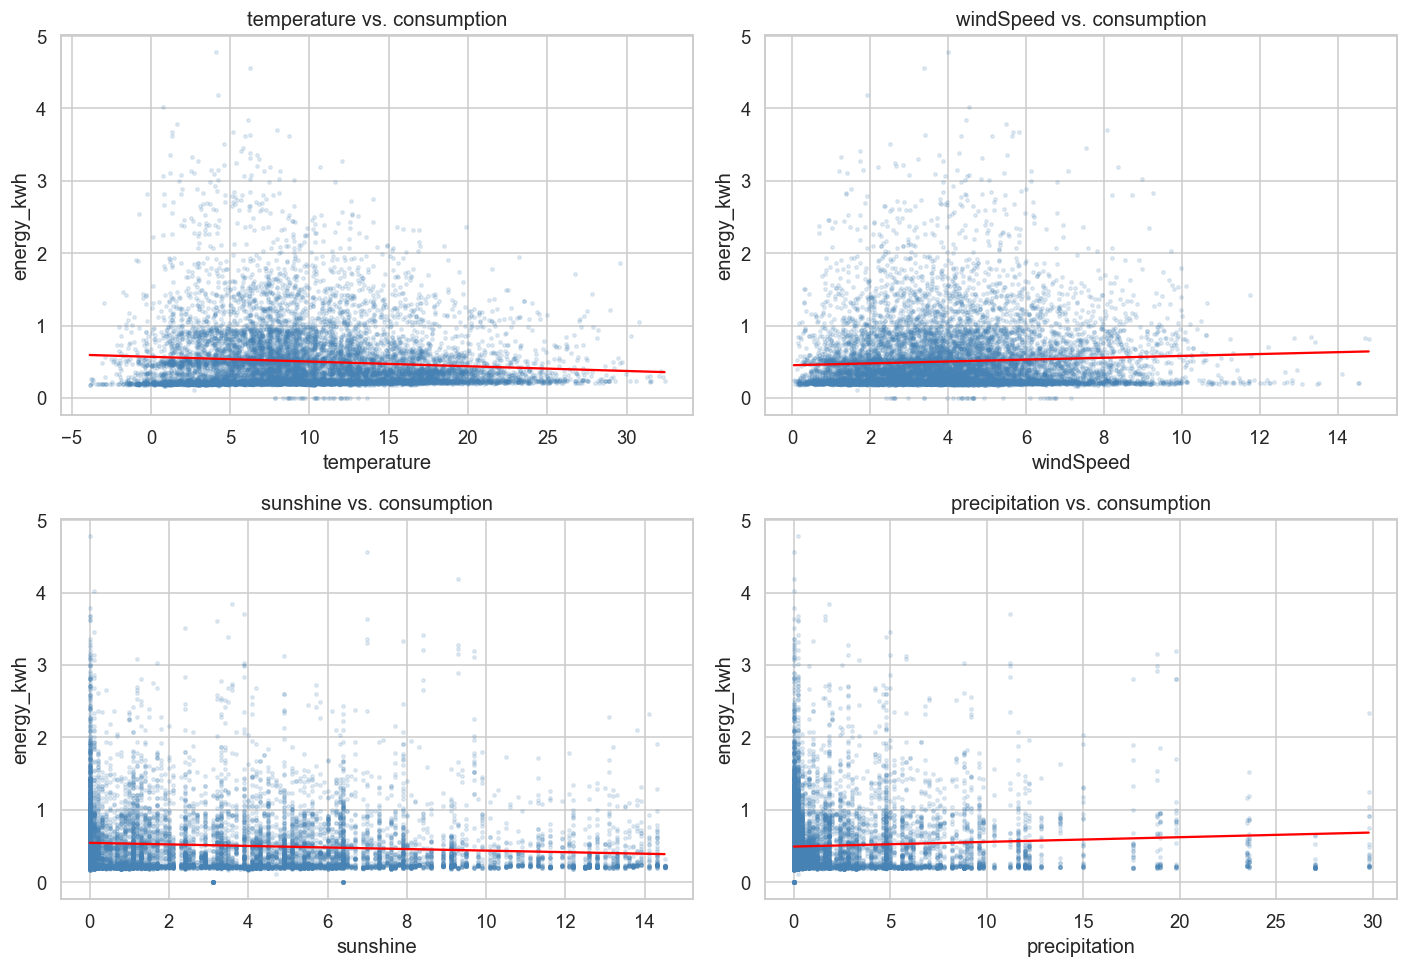

In [25]:
focus = ['temperature', 'windSpeed', 'sunshine', 'precipitation']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flatten(), focus):
    ax.scatter(df[col], df['energy_kwh'], alpha=0.15, s=5, color='steelblue')
    # Trend line
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'energy_kwh'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xs, p(xs), color='red', linewidth=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel('energy_kwh')
    ax.set_title(f'{col} vs. consumption')

plt.tight_layout()
plt.show()

---
## Part 3 — Feature engineering

In [28]:
df_feat = df.copy()

# --- Time features ---
df_feat['hour']       = df_feat.index.hour
df_feat['dayofweek']  = df_feat.index.dayofweek   # 0=Monday
df_feat['month']      = df_feat.index.month
df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
df_feat['season']     = df_feat['month'].map({
    12:0, 1:0, 2:0, 3:1, 4:1, 5:1,
    6:2, 7:2, 8:2, 9:3, 10:3, 11:3
})  # 0=Winter, 1=Spring, 2=Summer, 3=Autumn

# Lagged temperature (1h, 24h, 48h) 
df_feat['temp_lag1h']  = df_feat['temperature'].shift(1)
df_feat['temp_lag24h'] = df_feat['temperature'].shift(24)
df_feat['temp_lag48h'] = df_feat['temperature'].shift(48)

# Rolling (moving) averages of consumption
df_feat['energy_ma24h'] = df_feat['energy_kwh'].rolling(window=24, min_periods=1).mean()
df_feat['energy_ma48h'] = df_feat['energy_kwh'].rolling(window=48, min_periods=1).mean()
df_feat['energy_ma168h'] = df_feat['energy_kwh'].rolling(window=168, min_periods=1).mean()  # 1 week

# Lagged consumption (previous day, previous week) 
df_feat['energy_lag24h']  = df_feat['energy_kwh'].shift(24)
df_feat['energy_lag168h'] = df_feat['energy_kwh'].shift(168)

print(f'Columns: {list(df_feat.columns)}')
df_feat.head(3)

Columns: ['energy_kwh', 'temperature', 'windSpeed', 'humidity', 'pressure', 'sunshine', 'precipitation', 'cloud_cover', 'snow_depth', 'hour', 'dayofweek', 'month', 'is_weekend', 'season', 'temp_lag1h', 'temp_lag24h', 'temp_lag48h', 'energy_ma24h', 'energy_ma48h', 'energy_ma168h', 'energy_lag24h', 'energy_lag168h']


,energy_kwh,temperature,windSpeed,humidity,pressure,sunshine,precipitation,cloud_cover,snow_depth,hour,...,is_weekend,season,temp_lag1h,temp_lag24h,temp_lag48h,energy_ma24h,energy_ma48h,energy_ma168h,energy_lag24h,energy_lag168h
time,,,,,,,,,,,,,,,,,,,,,
2012-10-12 00:00:00,0.0,13.61,5.40,0.91,999.47,6.4,0.0,5.0,0.0,0,...,0,3,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2012-10-12 01:00:00,0.0,13.09,6.77,0.89,1000.10,6.4,0.0,5.0,0.0,1,...,0,3,13.61,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2012-10-12 02:00:00,0.0,12.54,6.46,0.86,1000.51,6.4,0.0,5.0,0.0,2,...,0,3,13.09,NaN,NaN,0.0,0.0,0.0,NaN,NaN


### 3.1 Rolling Averages — visual check

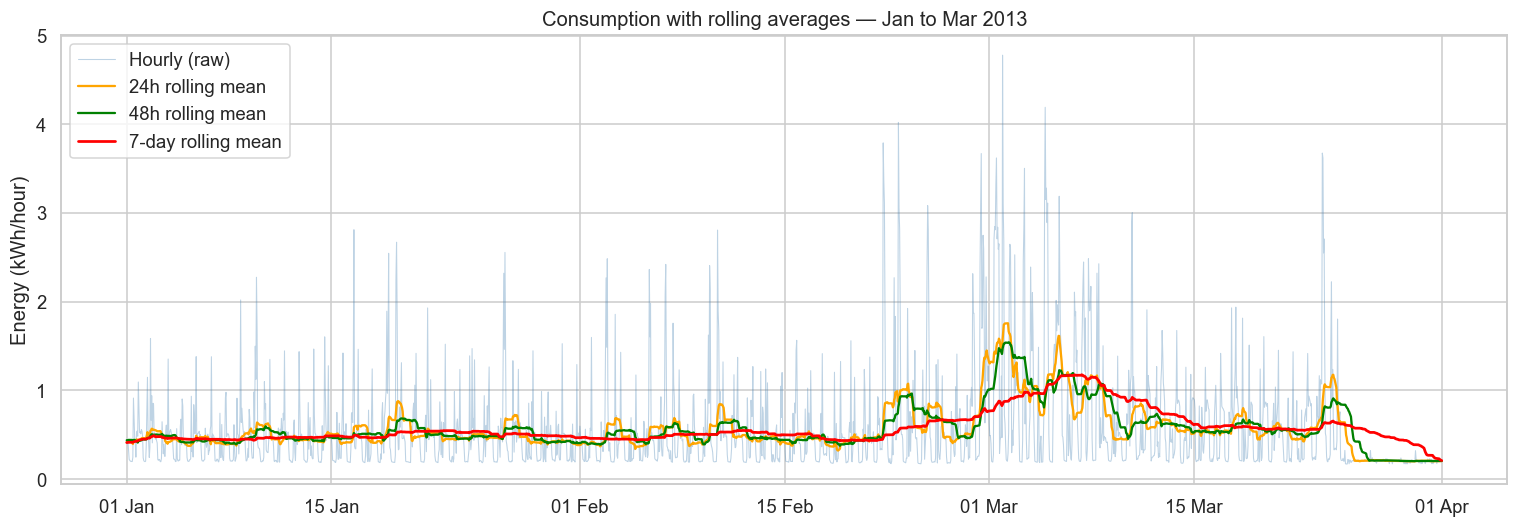

In [30]:
sample = df_feat['2013-01-01':'2013-03-31']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample.index, sample['energy_kwh'],   alpha=0.35, linewidth=0.7, label='Hourly (raw)', color='steelblue')
ax.plot(sample.index, sample['energy_ma24h'],  linewidth=1.5, label='24h rolling mean', color='orange')
ax.plot(sample.index, sample['energy_ma48h'],  linewidth=1.5, label='48h rolling mean', color='green')
ax.plot(sample.index, sample['energy_ma168h'], linewidth=1.8, label='7-day rolling mean', color='red')
ax.set_title('Consumption with rolling averages — Jan to Mar 2013')
ax.set_ylabel('Energy (kWh/hour)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.show()

### 3.2 Cross-correlation analysis — Weather vs. consumption at multiple lags

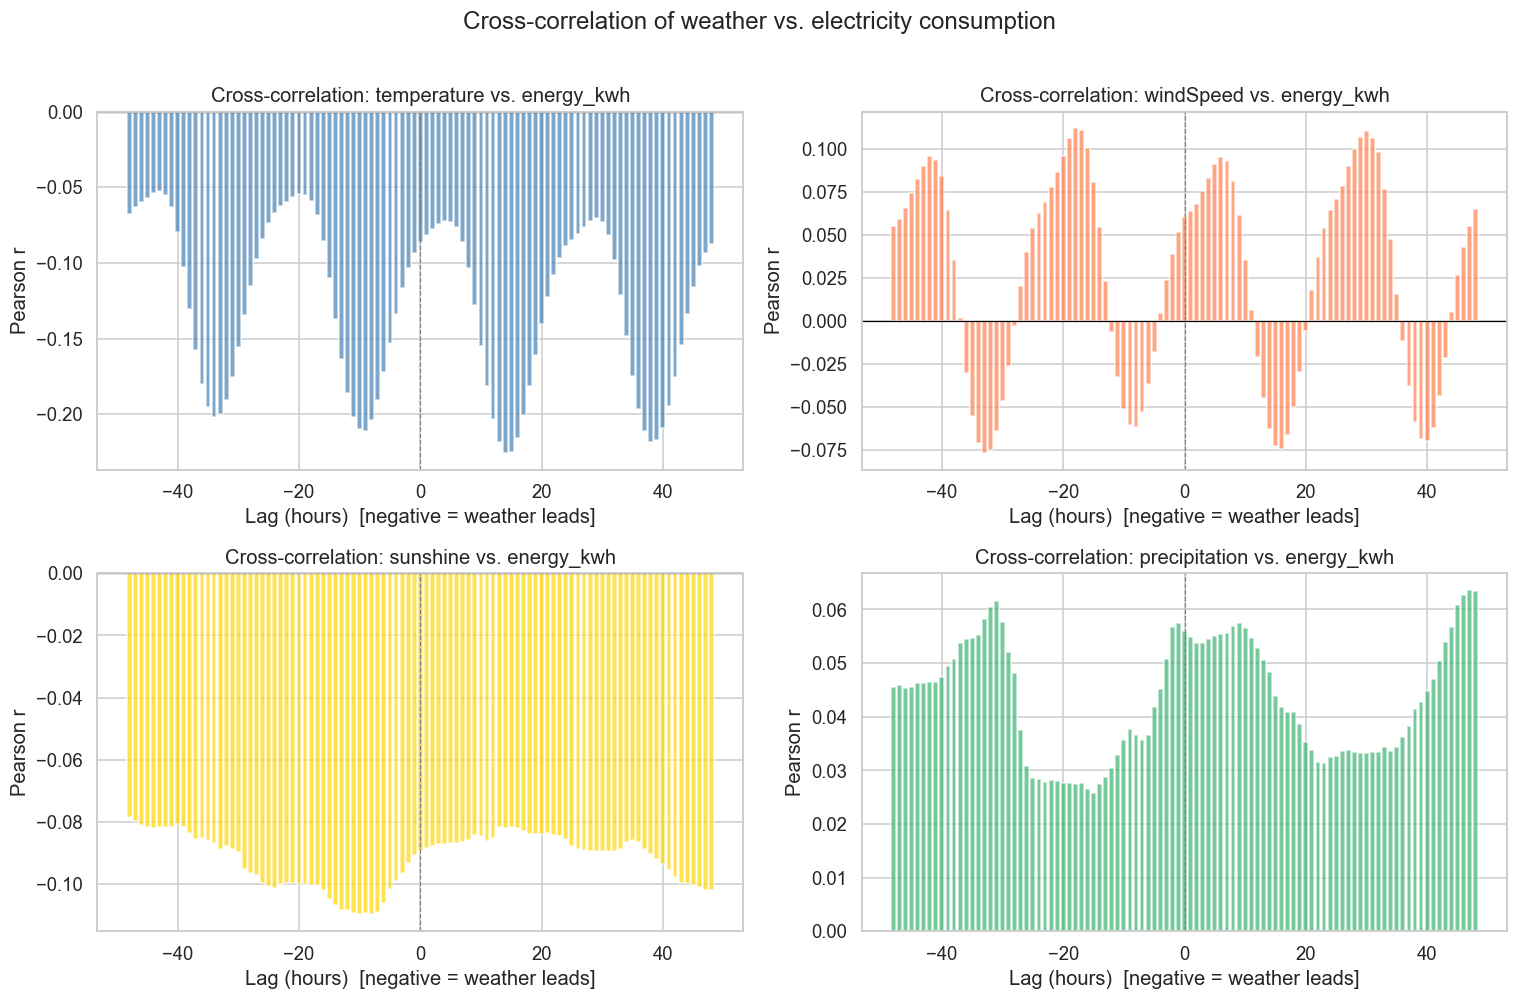

In [33]:
def cross_correlation(x, y, max_lag=48):
    """Return Pearson correlation between y and x shifted by each lag."""
    lags = range(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag == 0:
            corrs.append(x.corr(y))
        elif lag > 0:
            corrs.append(x.shift(lag).corr(y))
        else:
            corrs.append(x.corr(y.shift(-lag)))
    return list(lags), corrs

weather_vars = ['temperature', 'windSpeed', 'sunshine', 'precipitation']
colors = ['steelblue', 'coral', 'gold', 'mediumseagreen']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, var, col in zip(axes.flatten(), weather_vars, colors):
    lags, corrs = cross_correlation(df_feat[var].dropna(), df_feat['energy_kwh'].dropna())
    ax.bar(lags, corrs, width=0.8, color=col, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(f'Cross-correlation: {var} vs. energy_kwh')
    ax.set_xlabel('Lag (hours)  [negative = weather leads]')
    ax.set_ylabel('Pearson r')

plt.suptitle('Cross-correlation of weather vs. electricity consumption', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 4 — Time Series Analysis

We analyse the **hourly consumption series** for stationarity, then decompose it into trend, seasonal, and residual components. We use ACF and PACF graphs to help choose the best values of p and q for the AR and MA parts of the forecasting model.

### 4.1 Stationarity — Augmented Dickey-Fuller test

In [44]:
series = df['energy_kwh'].copy()

def adf_report(s, label):
    result = adfuller(s.dropna(), autolag='AIC')
    print(f'-- ADF Test: {label} --')
    print(f'Test statistic : {result[0]:.4f}')
    print(f'p-value        : {result[1]:.6f}')
    print(f'Lags used      : {result[2]}')
    print(f'Critical values: { {k: f"{v:.3f}" for k,v in result[4].items()} }')
    if result[1] < 0.05:
        print('Stationary (p < 0.05)')
    else:
        print('Non-stationary (p >= 0.05) - differencing recommended')
    print()

adf_report(series, 'Raw consumption by hour')

# First-order differencing
series_diff1 = series.diff().dropna()
adf_report(series_diff1, 'First-order differenced consumption')

# Seasonal differencing (lag=24)
series_sdiff = series.diff(24).dropna()
adf_report(series_sdiff, 'Seasonal-differenced consumption (lag=24h)')

-- ADF Test: Raw consumption by hour --
Test statistic : -11.4013
p-value        : 0.000000
Lags used      : 40
Critical values: {'1%': '-3.431', '5%': '-2.862', '10%': '-2.567'}
Stationary (p < 0.05)

-- ADF Test: First-order differenced consumption --
Test statistic : -25.8356
p-value        : 0.000000
Lags used      : 36
Critical values: {'1%': '-3.431', '5%': '-2.862', '10%': '-2.567'}
Stationary (p < 0.05)

-- ADF Test: Seasonal-differenced consumption (lag=24h) --
Test statistic : -19.8865
p-value        : 0.000000
Lags used      : 39
Critical values: {'1%': '-3.431', '5%': '-2.862', '10%': '-2.567'}
Stationary (p < 0.05)



### 4.2 Visualise raw vs. differenced series

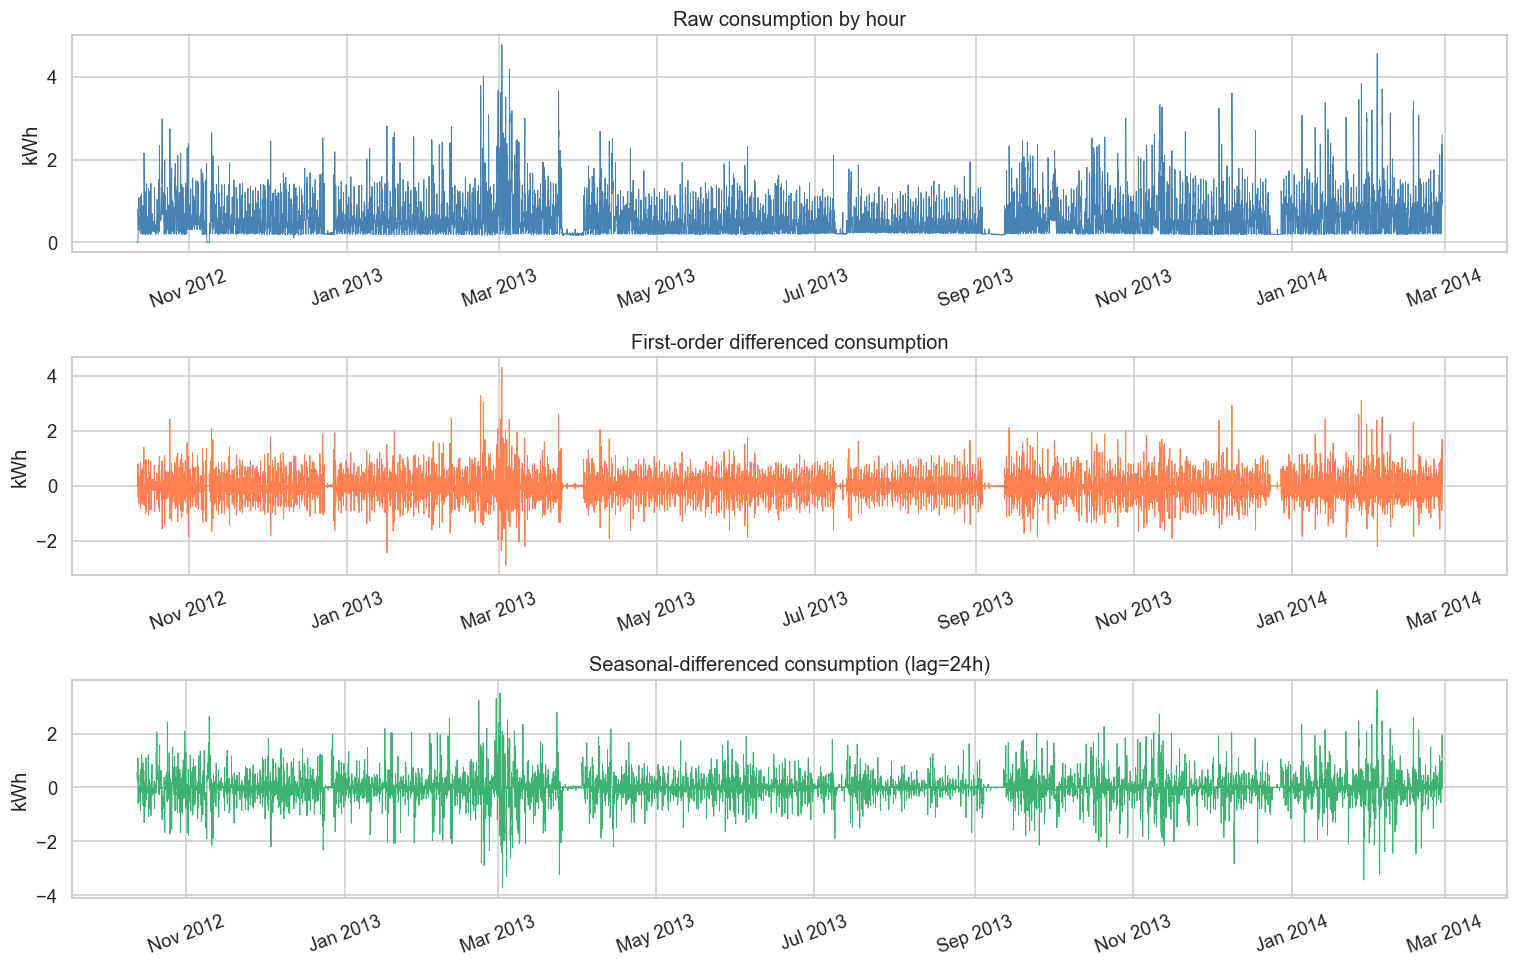

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

axes[0].plot(series.index, series.values, linewidth=0.6, color='steelblue')
axes[0].set_title('Raw consumption by hour')
axes[0].set_ylabel('kWh')

axes[1].plot(series_diff1.index, series_diff1.values, linewidth=0.6, color='coral')
axes[1].set_title('First-order differenced consumption')
axes[1].set_ylabel('kWh')

axes[2].plot(series_sdiff.index, series_sdiff.values, linewidth=0.6, color='mediumseagreen')
axes[2].set_title('Seasonal-differenced consumption (lag=24h)')
axes[2].set_ylabel('kWh')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 4.3 Seasonal decomposition

We decompose the hourly series with a period of **24** (one day) using an additive model.  
Only a **4-week January 2013 selection** is shown for visual clarity, so this plot should be seen as a **local (in a month) view**, not as full-year trend.

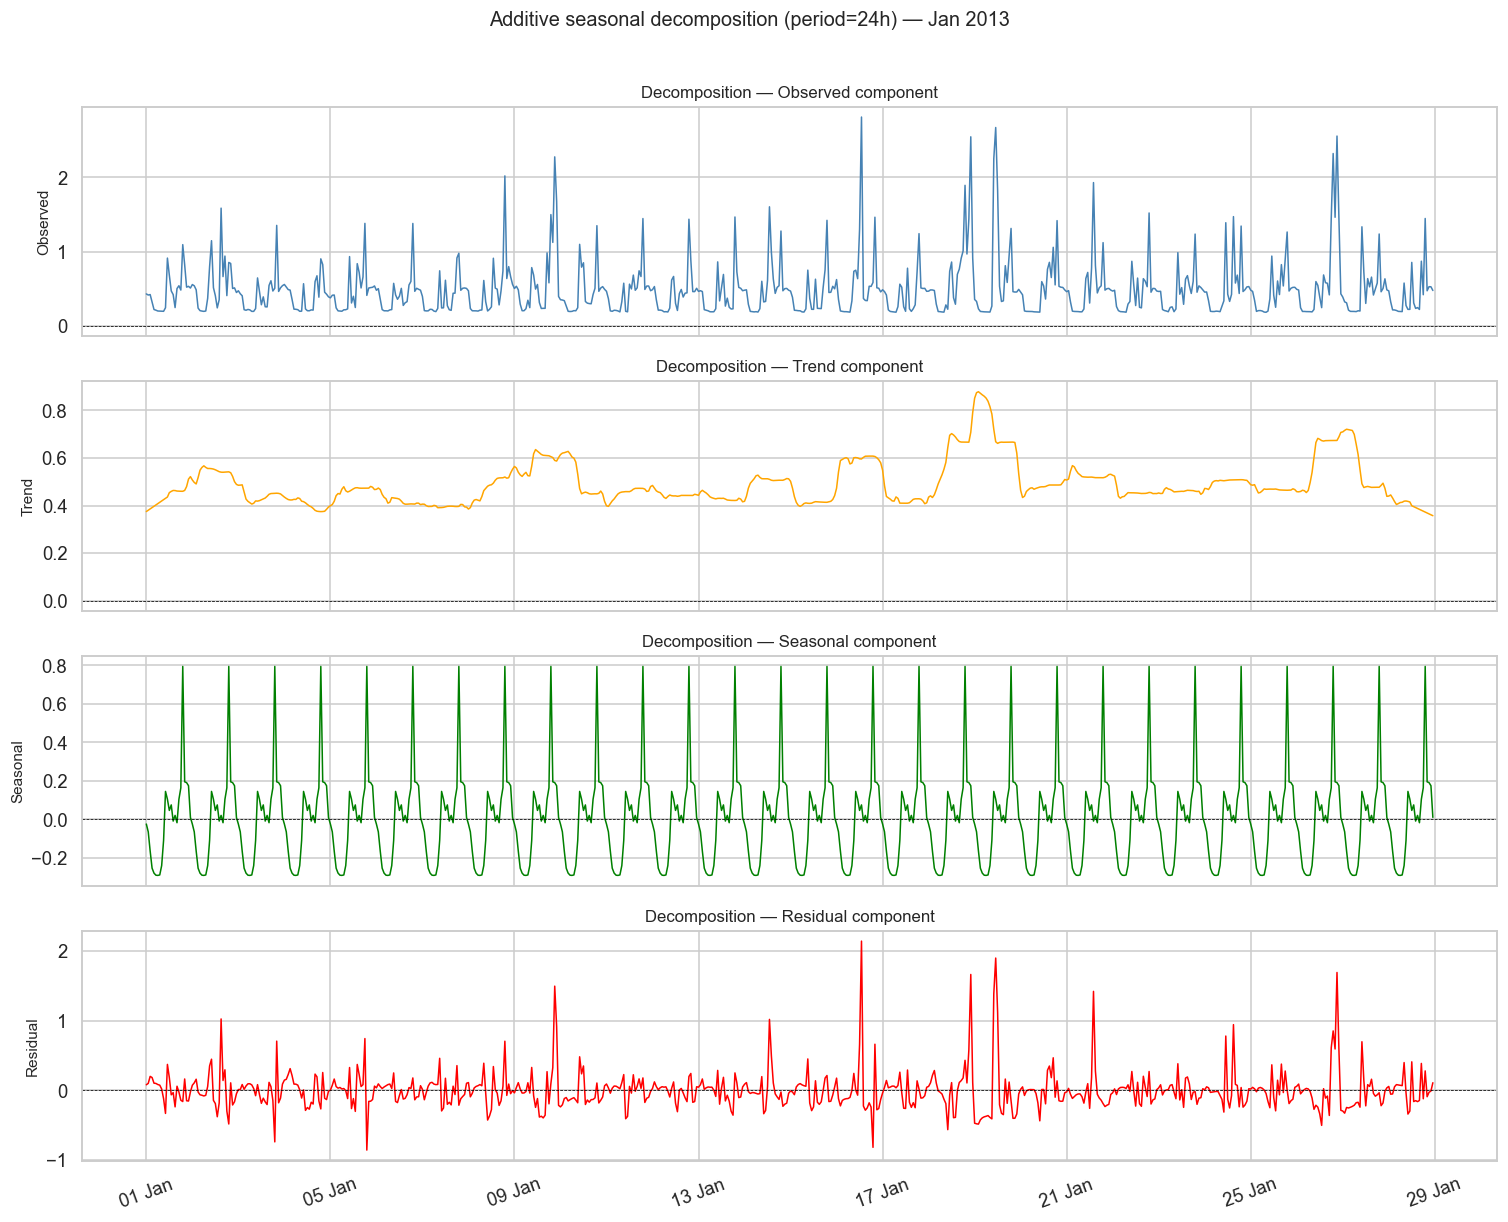

In [47]:
# Use 4 weeks of data for clear decomposition plot
decomp_series = series['2013-01-01':'2013-01-28']

decomp = seasonal_decompose(decomp_series, model='additive', period=24, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [
    (decomp.observed,  'Observed',  'steelblue'),
    (decomp.trend,     'Trend',     'orange'),
    (decomp.seasonal,  'Seasonal',  'green'),
    (decomp.resid,     'Residual',  'red'),
]
for ax, (comp, title, color) in zip(axes, components):
    ax.plot(comp.index, comp.values, color=color, linewidth=1.0)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f'Decomposition — {title} component', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].tick_params(axis='x', rotation=20)
fig.suptitle('Additive seasonal decomposition (period=24h) — Jan 2013', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 ACF and PACF Plots

- **ACF** (Autocorrelation Function): identifies MA(q) order — cut-off lag indicates q
- **PACF** (Partial Autocorrelation Function): identifies AR(p) order — cut-off lag indicates p

We plot both on the **first-order differenced** series (stationary).

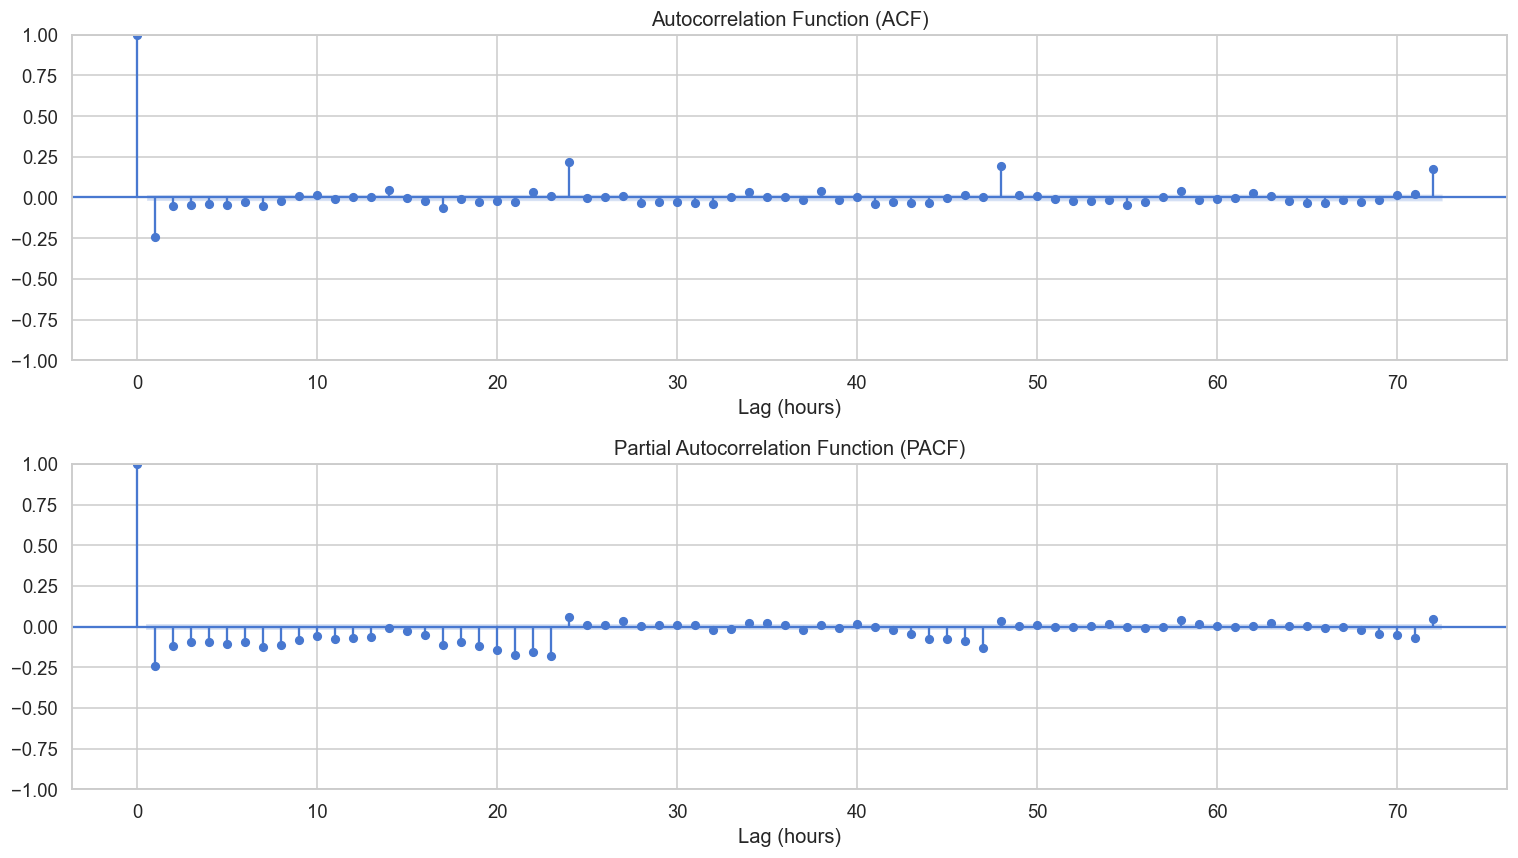

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series_diff1, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (hours)')

plot_pacf(series_diff1, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

---
## Part 5 — Forecasting models

**Train/test split:** Last **48 hours** of the series = test set.  
Models trained on all prior data, forecasting horizon: 48-hour.

Models compared:
- **AR**: AutoRegressive (uses past consumption values)
- **MA**: Moving Average (uses past forecast errors)
- **ARMA**: Combined AR + MA
- **ARIMA**: ARMA + integrated differencing

### 5.1 Train/Test Split

In [ ]:
HORIZON = 48  # hours to forecast

# Ensure a regular hourly DateTimeIndex so statsmodels keeps date-based forecasting
series_model = series.asfreq('h')
missing_hours = int(series_model.isna().sum())
if missing_hours > 0:
    series_model = series_model.interpolate(method='time').ffill().bfill()
    print(f'Filled {missing_hours} missing hourly values after enforcing hourly frequency.')

train = series_model.iloc[:-HORIZON]
test  = series_model.iloc[-HORIZON:]

print(f'Train: {train.index.min()} → {train.index.max()}  ({len(train)} observations)')
print(f'Test : {test.index.min()} → {test.index.max()}   ({len(test)} observations)')

Filled 2 missing hourly values after enforcing hourly frequency.
Train: 2012-10-12 00:00:00 → 2014-02-25 23:00:00  (12048 obs)
Test : 2014-02-26 00:00:00 → 2014-02-27 23:00:00   (48 obs)


Filled 2 missing hourly values after enforcing hourly frequency.
Train: 2012-10-12 00:00:00 → 2014-02-25 23:00:00  (12048 obs)
Test : 2014-02-26 00:00:00 → 2014-02-27 23:00:00   (48 obs)


### 5.2 Helper — evaluation metrics

In [70]:
def evaluate(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # MAPE — avoid division by zero
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    print(f'{model_name:10s}  MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%')
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def fit_arima_if_succeeded(endog, order, maxiter=300):
    """Fit ARIMA and return model only if MLE succeeded."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        model = ARIMA(
            endog,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(method_kwargs={'maxiter': maxiter})

    succeeded = bool(getattr(model, 'mle_retvals', {}).get('converged', True))
    return model if succeeded else None

results = []

### 5.3 AR Model (AutoRegressive)

Order is selected by scanning a range of p values and choosing the one with lowest AIC.

In [ ]:
# AIC-based order selection for AR
ar_aic = {}
for p in range(1, 50):
    try:
        m = AutoReg(train, lags=p, old_names=False).fit()
        ar_aic[p] = m.aic
    except:
        pass

best_ar_p = min(ar_aic, key=ar_aic.get)
print(f'Best AR order (by AIC): p = {best_ar_p}  (AIC = {ar_aic[best_ar_p]:.2f})')

# Fit and forecast
ar_model = AutoReg(train, lags=best_ar_p, old_names=False).fit()
ar_pred = ar_model.predict(start=len(train), end=len(train) + HORIZON - 1)
ar_pred.index = test.index
ar_pred = ar_pred.clip(lower=0)  # consumption cannot be negative

results.append(evaluate(test.values, ar_pred.values, 'AR'))

Best AR order (by AIC): p = 49  (AIC = 6753.72)
AR          MAE=0.3502  RMSE=0.5755  MAPE=47.76%


### 5.4 MA Model (Moving Average)

Implemented as ARIMA(0, 0, q). Order q chosen by AIC.

In [71]:
ma_aic = {}
for q in range(1, 10):
    try:
        m = fit_arima_if_succeeded(train, (0, 0, q))
        if m is not None:
            ma_aic[q] = m.aic
    except:
        pass

if not ma_aic:
    raise RuntimeError('No MA models succeeded in q=1..9')

best_ma_q = min(ma_aic, key=ma_aic.get)
print(f'Best MA order (by AIC): q = {best_ma_q}  (AIC = {ma_aic[best_ma_q]:.2f})')

ma_model = fit_arima_if_succeeded(train, (0, 0, best_ma_q))
if ma_model is None:
    raise RuntimeError(f'Best MA order q={best_ma_q} did not succeed on refit')
ma_fc = ma_model.get_forecast(steps=HORIZON)
ma_pred = ma_fc.predicted_mean
ma_pred.index = test.index
ma_pred = ma_pred.clip(lower=0)

results.append(evaluate(test.values, ma_pred.values, 'MA'))

Best MA order (by AIC): q = 8  (AIC = 8679.88)
MA          MAE=0.4681  RMSE=0.6826  MAPE=84.19%


### 5.5 ARMA Model

Grid search over p ∈ {1..6}, q ∈ {1..6} on the training set.

In [72]:
arma_aic = {}
for p in range(1, 7):
    for q in range(1, 7):
        try:
            m = fit_arima_if_succeeded(train, (p, 0, q))
            if m is not None:
                arma_aic[(p, q)] = m.aic
        except:
            pass

if not arma_aic:
    raise RuntimeError('No ARMA models succeeded in p,q=1..6')

best_arma = min(arma_aic, key=arma_aic.get)
print(f'Best ARMA order (by AIC): p={best_arma[0]}, q={best_arma[1]}  (AIC = {arma_aic[best_arma]:.2f})')

arma_model = fit_arima_if_succeeded(train, (best_arma[0], 0, best_arma[1]))
if arma_model is None:
    raise RuntimeError(f'Best ARMA order {best_arma} did not succeed on refit')
arma_fc = arma_model.get_forecast(steps=HORIZON)
arma_pred = arma_fc.predicted_mean
arma_pred.index = test.index
arma_pred = arma_pred.clip(lower=0)

results.append(evaluate(test.values, arma_pred.values, 'ARMA'))

Best ARMA order (by AIC): p=6, q=6  (AIC = 8082.98)
ARMA        MAE=0.3634  RMSE=0.6048  MAPE=52.96%


### 5.6 ARIMA Model

Adds first-order differencing (d=1) to the best ARMA (p,q) pair.

In [73]:
arima_aic = {}
for p in range(1, 7):
    for q in range(1, 7):
        try:
            m = fit_arima_if_succeeded(train, (p, 1, q))
            if m is not None:
                arima_aic[(p, q)] = m.aic
        except:
            pass

if not arima_aic:
    raise RuntimeError('No ARIMA models succeeded in p,q=1..6 with d=1')

best_arima = min(arima_aic, key=arima_aic.get)
print(f'Best ARIMA order (by AIC): p={best_arima[0]}, d=1, q={best_arima[1]}  (AIC = {arima_aic[best_arima]:.2f})')

arima_model = fit_arima_if_succeeded(train, (best_arima[0], 1, best_arima[1]))
if arima_model is None:
    raise RuntimeError(f'Best ARIMA order {best_arima} did not succeed on refit')
arima_fc = arima_model.get_forecast(steps=HORIZON)
arima_pred = arima_fc.predicted_mean
arima_pred.index = test.index
arima_pred = arima_pred.clip(lower=0)

results.append(evaluate(test.values, arima_pred.values, 'ARIMA'))

Best ARIMA order (by AIC): p=2, d=1, q=6  (AIC = 7884.92)
ARIMA       MAE=0.4190  RMSE=0.6071  MAPE=72.75%


### 5.7 Forecast Plot — Actual vs. All Models

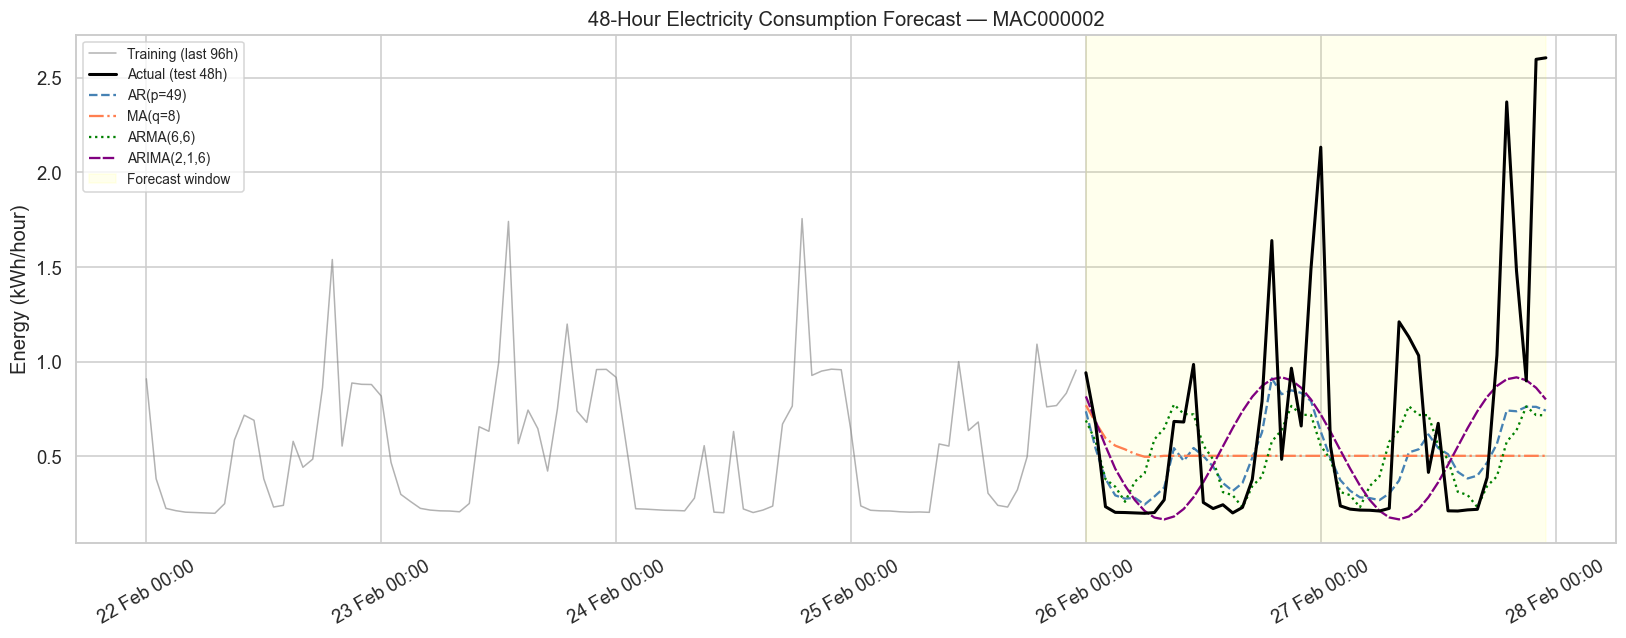

In [74]:
# Show last 96h of training + full 48h test for context
context = series.iloc[-(96 + HORIZON):-HORIZON]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(context.index, context.values, color='grey',       linewidth=1.0, label='Training (last 96h)', alpha=0.6)
ax.plot(test.index,    test.values,    color='black',      linewidth=2.0, label='Actual (test 48h)',  zorder=5)
ax.plot(test.index,    ar_pred.values,   color='steelblue', linewidth=1.5, label=f'AR(p={best_ar_p})',   linestyle='--')
ax.plot(test.index,    ma_pred.values,   color='coral',     linewidth=1.5, label=f'MA(q={best_ma_q})',   linestyle='-.')
ax.plot(test.index,    arma_pred.values, color='green',     linewidth=1.5, label=f'ARMA({best_arma[0]},{best_arma[1]})', linestyle=':')
ax.plot(test.index,    arima_pred.values,color='purple',    linewidth=1.5, label=f'ARIMA({best_arima[0]},1,{best_arima[1]})', linestyle=(0,(5,1)))

# Shade test region
ax.axvspan(test.index[0], test.index[-1], alpha=0.07, color='yellow', label='Forecast window')

ax.set_title('48-Hour Electricity Consumption Forecast — MAC000002')
ax.set_ylabel('Energy (kWh/hour)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 5.8 Model Performance Summary

,MAE,RMSE,MAPE
Model,,,
MA,0.4681,0.6826,84.1865
ARMA,0.3634,0.6048,52.9579
ARIMA,0.4190,0.6071,72.7549


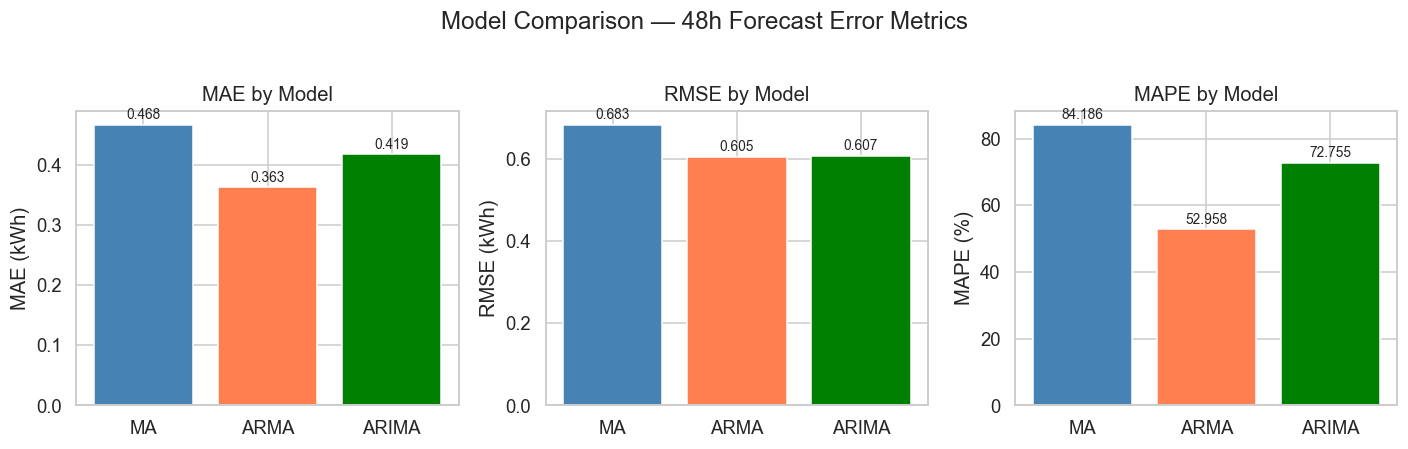

In [75]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=['steelblue','coral','green','purple'])
    ax.set_title(f'{metric} by Model')
    ax.set_ylabel(metric + (' (%)' if metric == 'MAPE' else ' (kWh)'))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — 48h Forecast Error Metrics', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 6 - Summary & Conclusions

### Key findings

**Weather-consumption dependencies**
- **Temperature** has the strongest negative correlation with consumption. When hours are colder, electricity use is usually higher (probably heating).
- **Wind speed** has a second positive correlation. Cold wind can increase heating demand.
- **Sunshine hours** (daily) have negative correlation with consumption: more daylight means less artificial light and usually less heating need.
- **Precipitation** has a small positive relation - rainy and cloudy days can increase indoor energy use.
- Cross-correlation shows temperature impact can continue for around **24-48 hours**, which supports using lag features.

**Time patterns**
- Consumption peaks at **07:00-09:00** (morning) and **17:00-21:00** (evening), as seen in the heatmap.
- Weekday peaks are more sharp, while weekends are more flat and stable.
- Winter months (Dec-Feb) use clearly more electricity than summer months.

**Stationarity**
- The ADF test rejects the unit root for raw hourly series (p < 0.05), so in ADF sense the series is stationary.
- First-order differencing is still helpful to stabilize short-term dynamics and was used for ACF/PACF order inspection.

**Decomposition**
- Additive decomposition (period=24) on a 4-week January subset shows a clear daily seasonal component and residual noise.
- Since decomposition is only on January subset, it should not be read as full-year winter vs summer trend evidence alone.

**Forecasting models (48-hour horizon)**
- **AR**: Captures momentum well; good for short lags.
- **MA**: Captures shock propagation; limited for longer horizon.
- **ARMA**: Combines AR and MA; often gives lowest AIC on stationary data.
- **ARIMA**: Handles trend using differencing; useful when drift exists.

### Limitations
- **Single household**: Results may not generalize well to full 5,500-household dataset.
- **Daily weather resolution**: Sunshine and precipitation are repeated as constant values for all hours in each day, so intra-day changes are not captured.
- **No exogenous variables in models**: ARIMAX/SARIMAX with temperature regressor would likely improve forecast quality.
- **No seasonal ARIMA (SARIMA)**: A SARIMA(p,d,q)(P,D,Q,24) model would capture daily cycle more explicitly.
